# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/data/home_tasks/yulu_rental.csv')

df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

df.head()

Mounted at /content/drive


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,weekday,weekday_num,week,year,day
datetime,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,0,Saturday,5,52,2011,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,Saturday,5,52,2011,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1,2,Saturday,5,52,2011,1
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,1,3,Saturday,5,52,2011,1
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,1,4,Saturday,5,52,2011,1


## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [3]:
monthly_avg = df['count'].resample('M').mean()

/tmp/ipython-input-346/2011312540.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df['count'].resample('M').mean()


In [4]:
monthly_avg = df['count'].resample('M').mean()

/tmp/ipython-input-346/2011312540.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = df['count'].resample('M').mean()


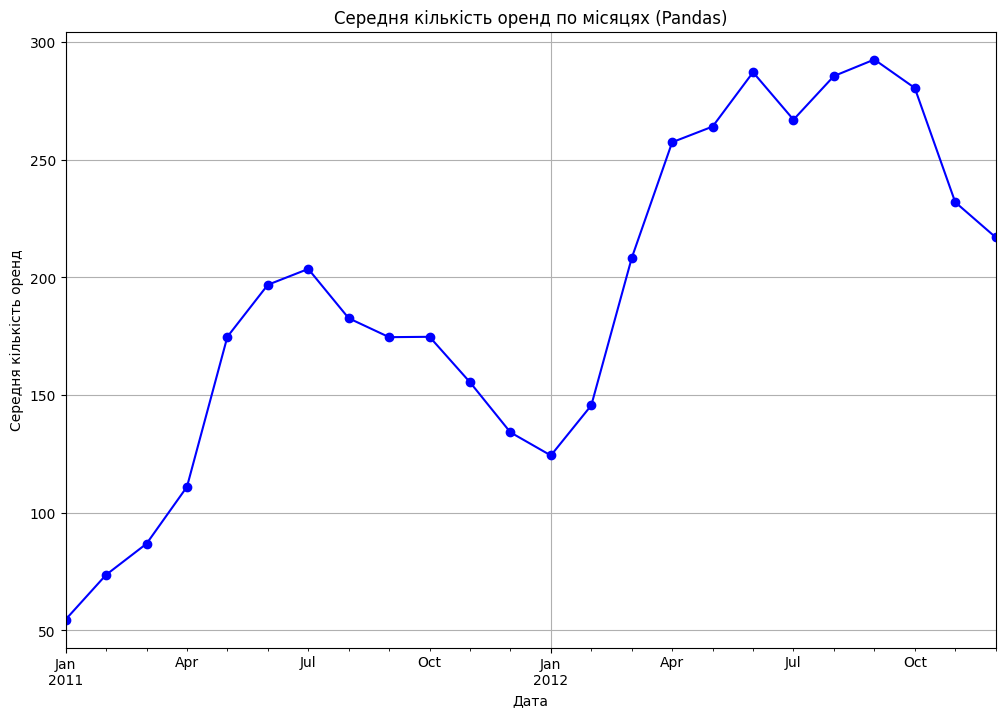

In [16]:

monthly_avg.plot(
    figsize=(12,8),
    marker='o',
    color='blue',
    title='Середня кількість оренд по місяцях (Pandas)',
    grid=True
)

plt.xlabel('Дата')
plt.ylabel('Середня кількість оренд')

plt.show()

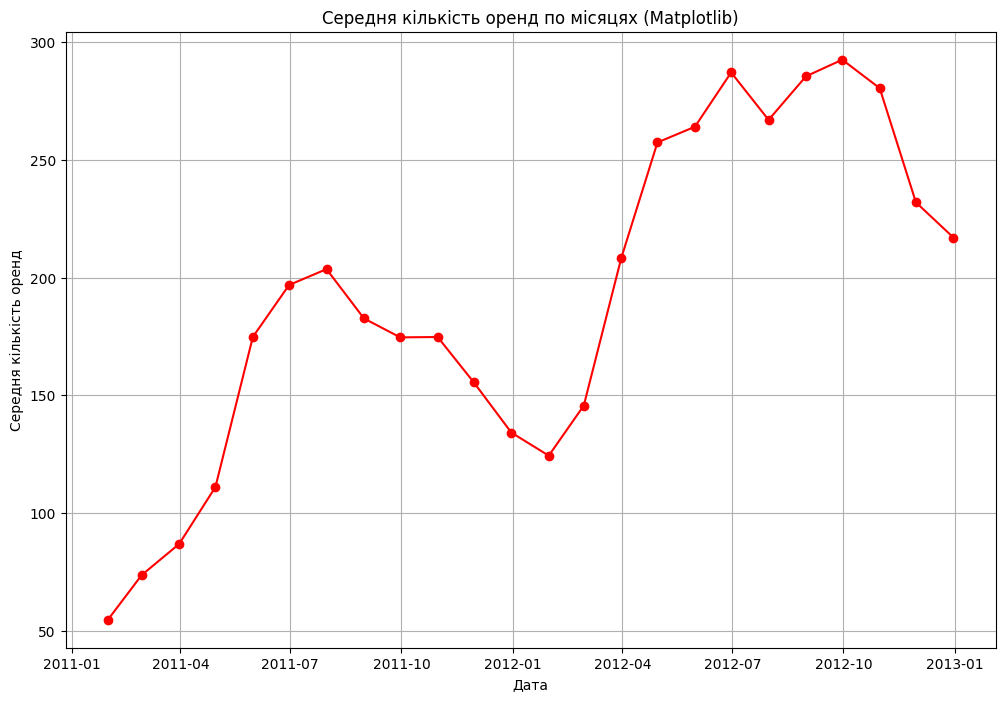

In [18]:
plt.figure(figsize=(12,8))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker='o',
    color='red'
)

plt.title('Середня кількість оренд по місяцях (Matplotlib)')
plt.xlabel('Дата')
plt.ylabel('Середня кількість оренд')

plt.grid(True)

plt.show()

Побудовані два однакових графіка за допомогою Pandas та Matplotlib.
Обидва графіки відображають однакову інформацію, але відрізняються способом побудови. Візуально графіки не відрізняються. Pandas більш простий у використанні, Matplotlib дає більше можливостей, але складніший у написанні.Особисто для мене більш зручний і простіший Pandas.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [21]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

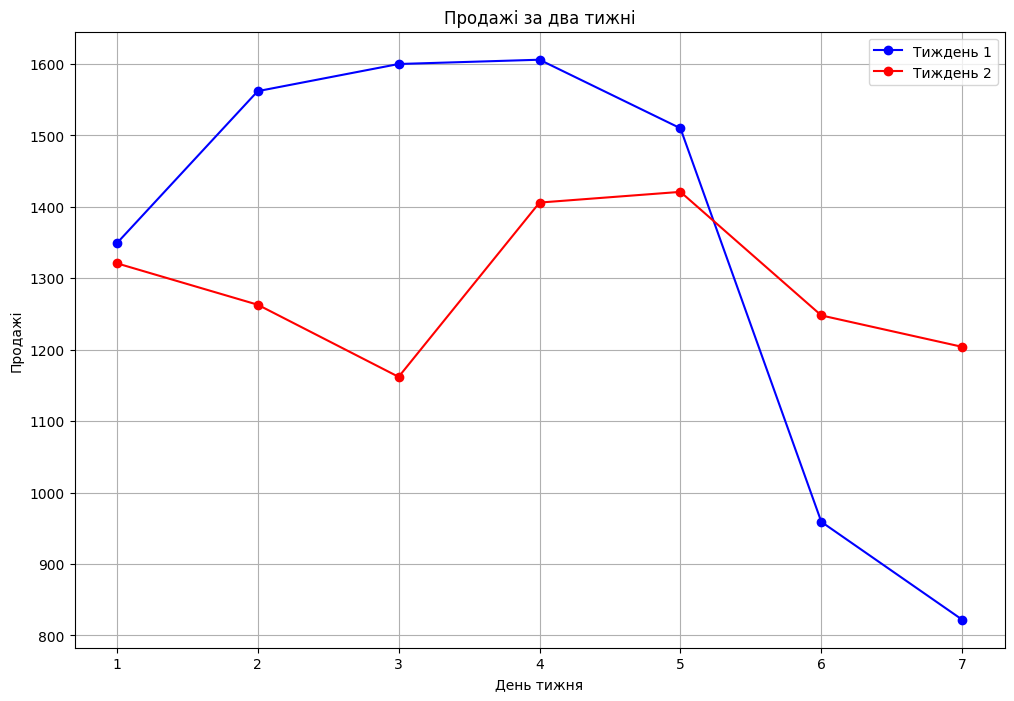

In [22]:
plt.figure(figsize=(12,8))

plt.plot(days, sales_week1, marker='o', label='Тиждень 1', color='blue')
plt.plot(days, sales_week2, marker='o', label='Тиждень 2', color='red')


plt.title('Продажі за два тижні')

plt.xlabel('День тижня')
plt.ylabel('Продажі')

plt.legend()

plt.grid(True)

plt.show()

Продажі у другому тижні були більш стабільними, оскільки вони змінювались більш рівномірно без різких спадів як у першому тижні.

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

In [ ]:
monthly_temp = df.resample('M')['temp'].mean()


/tmp/ipython-input-591/4213352478.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = df.resample('M')['temp'].mean()


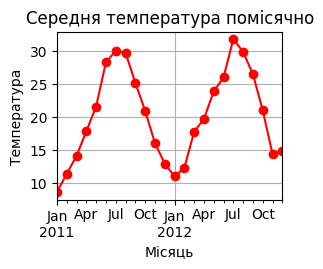

In [ ]:
plt.subplot(2,2,1)

monthly_temp.plot(
    marker='o',
    color='red'
)

plt.title('Середня температура помісячно')
plt.xlabel('Місяць')
plt.ylabel('Температура')
plt.grid(True)

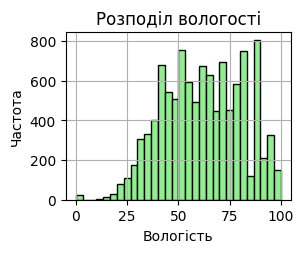

In [ ]:
plt.subplot(2,2,3)

plt.hist(
    df['humidity'],   # ✅ ось правильно
    bins=30,
    color='lightgreen',
    edgecolor='black'
)

plt.title('Розподіл вологості')
plt.xlabel('Вологість')
plt.ylabel('Частота')
plt.grid(True)


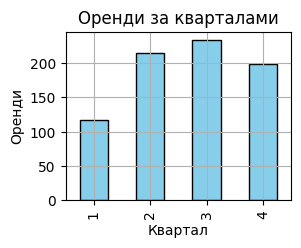

In [ ]:
plt.subplot(2,2,2)
quarter_avg = df.groupby('season')['count'].mean()
quarter_avg.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Оренди за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Оренди')
plt.grid(True)

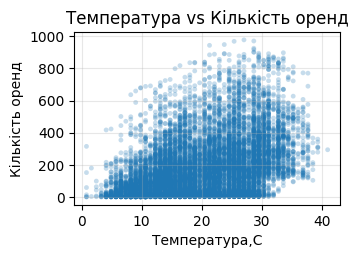

In [ ]:
plt.subplot(2,2,4)

plt.scatter(
    df['temp'], df['count'],
    alpha=0.25,
    s=12,
    edgecolors='none'
)

plt.title('Температура vs Кількість оренд')
plt.xlabel('Температура,C')
plt.ylabel('Кількість оренд')
plt.grid(True, alpha=0.3)


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

In [ ]:
monthly_temp = df.resample('M')['temp'].mean()
quarterly_count = df.groupby(df.index.quarter)['count'].mean()
humidity = df['humidity']



/tmp/ipython-input-591/935470791.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = df.resample('M')['temp'].mean()


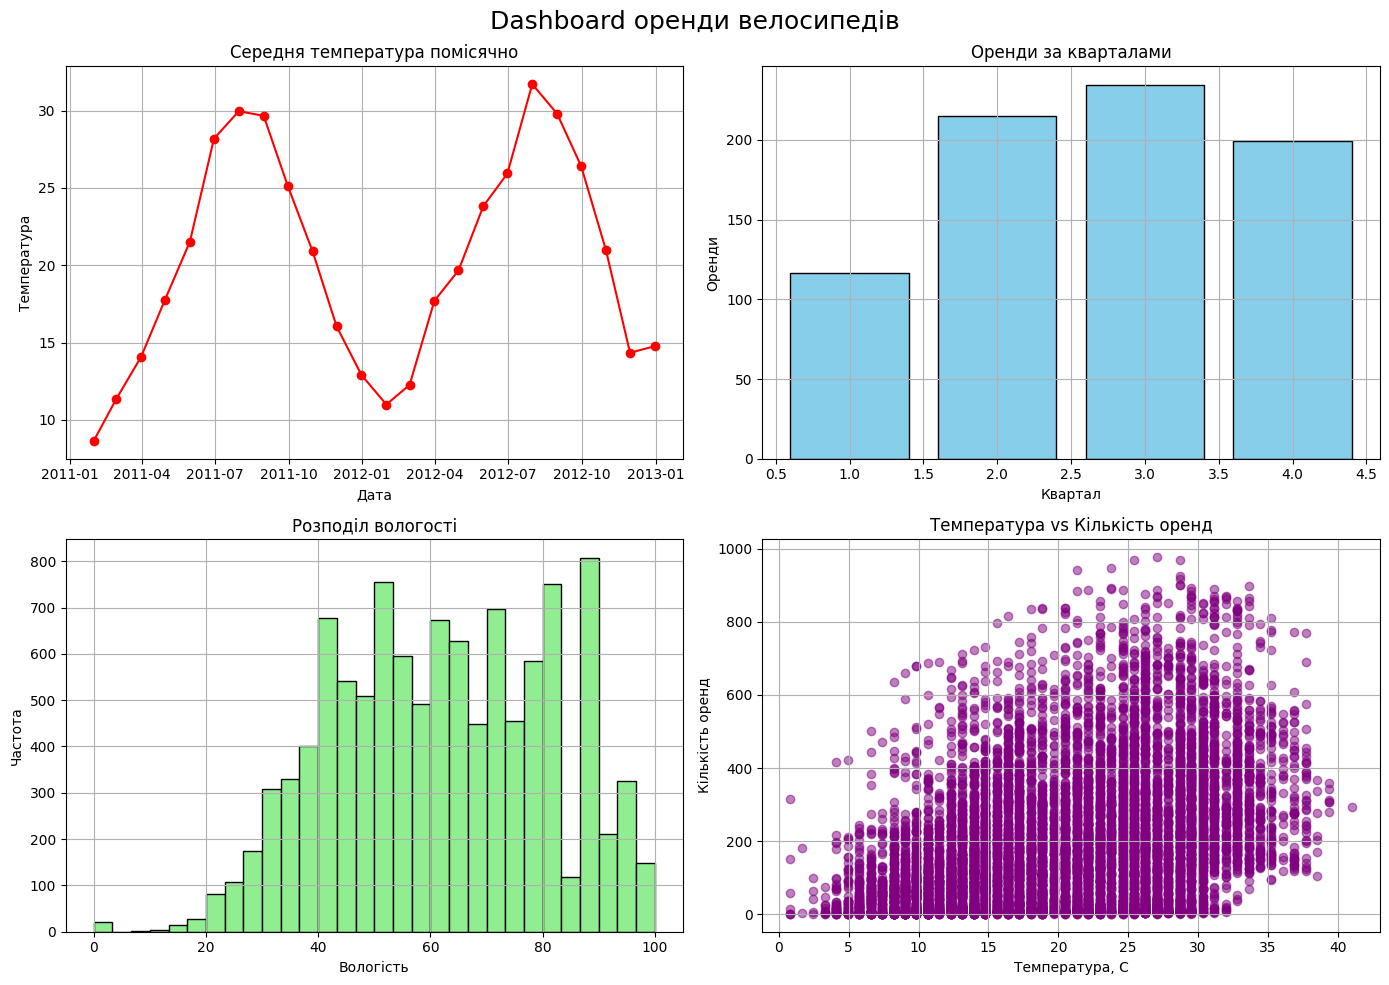

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(14,10))

# графік 1
ax[0,0].plot(
    monthly_temp.index,
    monthly_temp,
    marker='o',
    color='red'
)

ax[0,0].set_title('Середня температура помісячно')
ax[0,0].set_xlabel('Дата')
ax[0,0].set_ylabel('Температура')
ax[0,0].grid(True)


# графік 2
ax[1,0].hist(
    humidity,
    bins=30,
    color='lightgreen',
    edgecolor='black'
)

ax[1,0].set_title('Розподіл вологості')
ax[1,0].set_xlabel('Вологість')
ax[1,0].set_ylabel('Частота')
ax[1,0].grid(True)

# графік 3

ax[0,1].bar(
    quarterly_count.index,
    quarterly_count,
    color='skyblue',
    edgecolor='black'
)

ax[0,1].set_title('Оренди за кварталами')
ax[0,1].set_xlabel('Квартал')
ax[0,1].set_ylabel('Оренди')
ax[0,1].grid(True)

# графік 4
ax[1,1].scatter(
    df['temp'],
    df['count'],
    alpha=0.5,
    color='purple'
)

ax[1,1].set_title('Температура vs Кількість оренд')
ax[1,1].set_xlabel('Температура, С')
ax[1,1].set_ylabel('Кількість оренд')
ax[1,1].grid(True)

fig.suptitle(
    'Dashboard оренди велосипедів',
    fontsize=18
)

plt.tight_layout()

plt.show()



Підхід plt.subplot() є більш простим, але менш зручним, всі налаштування виконуються через plt. Підхід fig, ax = plt.subplots() є більш  гнучким, ми можемо налаштовувати кожен графік окремо через відповідний елемент ax. Це робить код більш зрозумілим, структурованим і зручним для роботи. Для мене більш зручний plt.subplots().

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

In [ ]:
# групування по місяцях
monthly = df.resample('M')['count'].agg(['mean','max','min'])


# середнє за весь період
overall_mean = df['count'].mean()


# Максимум і мінімум середнього
max_month = monthly['mean'].idxmax()
min_month = monthly['mean'].idxmin()

max_value = monthly['mean'].max()
min_value = monthly['mean'].min()

/tmp/ipython-input-591/1103238156.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.resample('M')['count'].agg(['mean','max','min'])


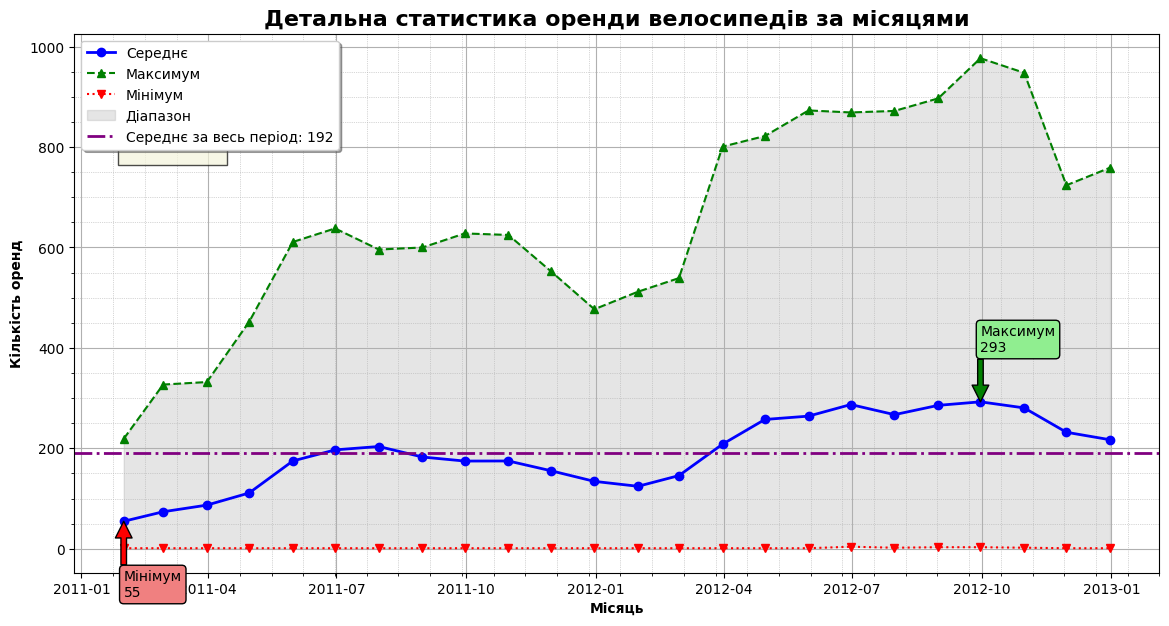

In [ ]:
# Створюємо графік
plt.figure(figsize=(14,7))


# Середнє
plt.plot(
    monthly.index,
    monthly['mean'],
    color='blue',
    marker='o',
    linestyle='-',
    linewidth=2,
    label='Середнє'
)


# Максимум
plt.plot(
    monthly.index,
    monthly['max'],
    color='green',
    marker='^',
    linestyle='--',
    label='Максимум'
)


# Мінімум
plt.plot(
    monthly.index,
    monthly['min'],
    color='red',
    marker='v',
    linestyle=':',
    label='Мінімум'
)



# Заливка області
plt.fill_between(
    monthly.index,
    monthly['min'],
    monthly['max'],
    color='gray',
    alpha=0.2,
    label='Діапазон'
)



# Горизонтальна лінія середнього
plt.axhline(
    overall_mean,
    color='purple',
    linestyle='-.',
    linewidth=2,
    label=f'Середнє за весь період: {overall_mean:.0f}'
)



# Анотація максимуму
plt.annotate(
    f'Максимум\n{max_value:.0f}',
    xy=(max_month, max_value),
    xytext=(max_month, max_value+100),
    arrowprops=dict(facecolor='green'),
    bbox=dict(boxstyle="round", fc="lightgreen")
)



# Анотація мінімуму
plt.annotate(
    f'Мінімум\n{min_value:.0f}',
    xy=(min_month, min_value),
    xytext=(min_month, min_value-150),
    arrowprops=dict(facecolor='red'),
    bbox=dict(boxstyle="round", fc="lightcoral")
)



# Статистика текст
stats = f'''
Статистика:
Середнє: {monthly['mean'].mean():.0f}
Макс: {monthly['mean'].max():.0f}
Мін: {monthly['mean'].min():.0f}
Std: {monthly['mean'].std():.0f}
'''


plt.text(
    monthly.index[0],
    monthly['max'].max()*0.8,
    stats,
    bbox=dict(facecolor='beige', alpha=0.7)
)



# Сітка
plt.grid(True)
plt.minorticks_on()
plt.grid(which='minor', linestyle=':', linewidth=0.5)



# Заголовок
plt.title(
    'Детальна статистика оренди велосипедів за місяцями',
    fontsize=16,
    fontweight='bold'
)


# Підписи
plt.xlabel('Місяць', fontweight='bold')
plt.ylabel('Кількість оренд', fontweight='bold')



# Легенда
plt.legend(
    shadow=True,
    fancybox=True
)



plt.show()

Анотації допомагають швидко побачити ключові точки на графіку.Це спрощує аналіз і дозволяє одразу звернути увагу на важливі моменти. fill_between() використовується для заповнення області між двома лініями, тобто він показує діапазон між мінімальними та максимальними значеннями, завдяки цьому можемо оцінити розкид даних.Текстовий блок містить основні показники, такі як середнє, максимум і мінімум. Це дозволяє швидко отримати узагальнену інформацію без додаткового аналізу графіка.